# IMPORT

----------------

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

In [2]:
import kagglehub

path = kagglehub.dataset_download("shivamshinde123/autismprediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'autismprediction' dataset.
Path to dataset files: /kaggle/input/autismprediction


In [3]:
import os

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/autismprediction/train.csv
/kaggle/input/autismprediction/test.csv


In [4]:
csv_files = []

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith(".csv"):
            csv_files.append(os.path.join(dirname, filename))

csv_files

['/kaggle/input/autismprediction/train.csv',
 '/kaggle/input/autismprediction/test.csv']

-------------------

# Load and Explore Dataset


----------------

In [5]:
df = pd.read_csv(csv_files[0])
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [6]:
df.shape

(800, 22)

In [7]:
df.isnull().sum()

,0
ID,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0


In [8]:
df["Class/ASD"].value_counts()

,count
Class/ASD,
0,639
1,161


The target column `Class/ASD` is imbalanced. Class 0 has 639 samples, while Class 1 has 161 samples. This means one class appears much more than the other. Because of this, accuracy alone may not be enough to evaluate the model, so I will use F1-score as the main metric.

--------------

# Prepare the Data


In [9]:
X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]

In [10]:
X = pd.get_dummies(X, drop_first=True)

In [11]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

I converted the categorical columns into numeric columns using `pd.get_dummies()` so the machine learning models can train on the data.

The dataset was split into 80% training data and 20% testing data using `random_state=42`. I used `stratify=y` because the target column is imbalanced, so the class distribution stays similar in both training and testing sets.

------------------

# Train and Compare Models

----------------------------

Logistic Regression model


In [12]:
log_model = LogisticRegression(max_iter=5000)

In [13]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [14]:
y_pred_log = log_model.predict(X_test)

In [15]:
acc_log = accuracy_score(y_test, y_pred_log)
pre_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Accuracy:", acc_log, "Precision:", pre_log, "Recall:", rec_log, "F1-score:", f1_log)

Accuracy: 0.85625 Precision: 0.6216216216216216 Recall: 0.71875 F1-score: 0.6666666666666666


The Log model achieved good accuracy but since the dataset is imbalanced i focused more on the F1-score the F1-score was 0.67 which shows that the model has a fair balance between precision and recall

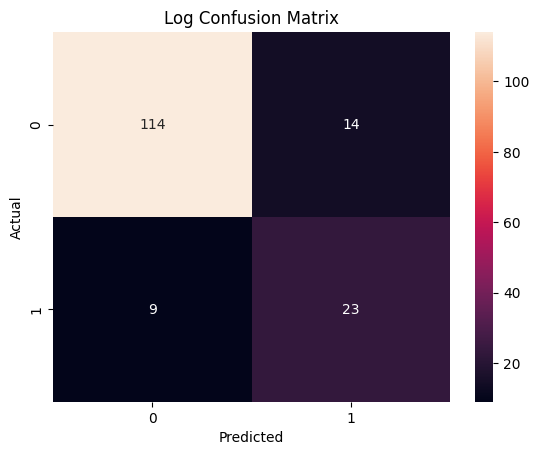

In [16]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt="d")
plt.title("Log Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest model

In [17]:
rf_model = RandomForestClassifier(random_state=42)

In [18]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
y_pred_rf = rf_model.predict(X_test)

In [20]:
acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy:", acc_rf, "Precision:", pre_rf, "Recall:", rec_rf, "F1-score:", f1_rf)

Accuracy: 0.85625 Precision: 0.6551724137931034 Recall: 0.59375 F1-score: 0.6229508196721312


The Rf model achieved the same accuracy as Log but its F1-score was lower Since the dataset is imbalanced F1-score is more important than accuracy so Log is still better so far

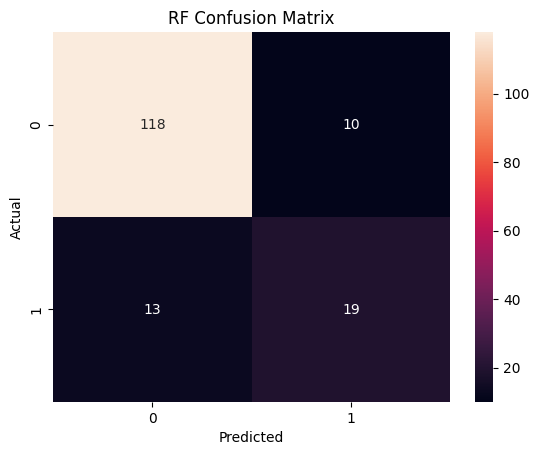

In [21]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("RF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN

In [22]:
knn_model = KNeighborsClassifier()

In [23]:
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [24]:
y_pred_knn = knn_model.predict(X_test)

In [25]:
acc_knn = accuracy_score(y_test, y_pred_knn)
pre_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("Accuracy:", acc_knn, "Precision:", pre_knn, "Recall:", rec_knn, "F1-score:", f1_knn)

Accuracy: 0.78125 Precision: 0.4 Recall: 0.1875 F1-score: 0.2553191489361702


The KNN model had the lowest F1-score compared to the other models so it was not selected as the best model

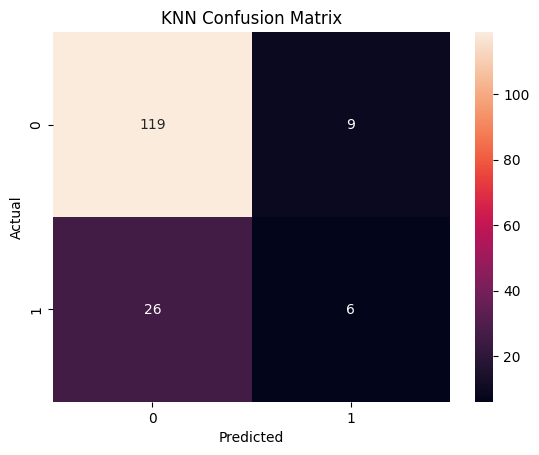

In [26]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt="d")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

AI

In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN"],
    "Accuracy": [acc_log, acc_rf, acc_knn],
    "Precision": [pre_log, pre_rf, pre_knn],
    "Recall": [rec_log, rec_rf, rec_knn],
    "F1-score": [f1_log, f1_rf, f1_knn]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.85625,0.621622,0.71875,0.666667
1,Random Forest,0.85625,0.655172,0.59375,0.622951
2,KNN,0.78125,0.400000,0.18750,0.255319


In [28]:
best_model = "Logistic Regression"

print("Best model:", best_model)

Best model: Logistic Regression


The best model is Logistic Regression because it achieved the highest F1-score Since the dataset is imbalanced F1-score is the main metric

---------------

# Build and Train

----------------

In [36]:
np.random.seed(42)
tf.random.set_seed(42)

In [37]:
nn_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [39]:
history = nn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5371 - loss: 11.8981 - val_accuracy: 0.7969 - val_loss: 6.3913
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7539 - loss: 5.5914 - val_accuracy: 0.7969 - val_loss: 3.3002
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7051 - loss: 3.4204 - val_accuracy: 0.7969 - val_loss: 2.9748
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6543 - loss: 3.9458 - val_accuracy: 0.7969 - val_loss: 2.6259
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6426 - loss: 3.6258 - val_accuracy: 0.7969 - val_loss: 3.1226
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6582 - loss: 2.8088 - val_accuracy: 0.7969 - val_loss: 1.9321
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6602 - loss: 2.3482 - val_accuracy: 0.7969 - val_loss: 2.8543
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6465 - loss: 2.1632 - val_accuracy: 0.7969 - va

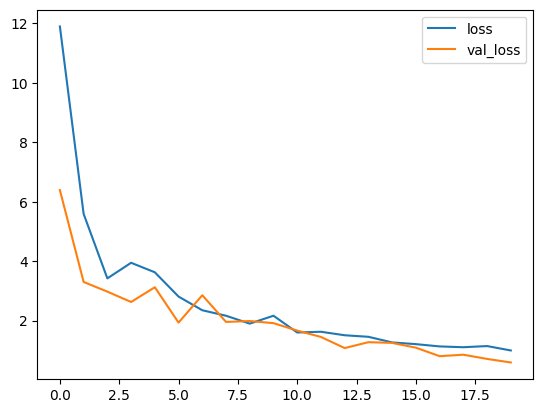

In [40]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

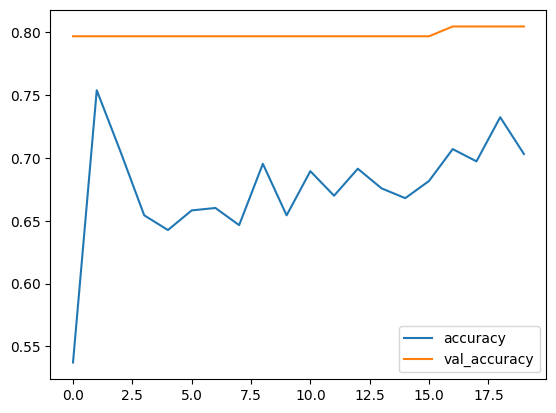

In [41]:
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.show()

-------------

# Compare with Step 1

-----------

In [42]:
y_pred_nn = nn_model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


In [43]:
y_pred_nn = (y_pred_nn > 0.5).astype("int32")

In [44]:
acc_nn = accuracy_score(y_test, y_pred_nn)
pre_nn = precision_score(y_test, y_pred_nn)
rec_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

print("Accuracy:", acc_nn, "Precision:", pre_nn, "Recall:", rec_nn, "F1-score:", f1_nn)

Accuracy: 0.8125 Precision: 1.0 Recall: 0.0625 F1-score: 0.11764705882352941


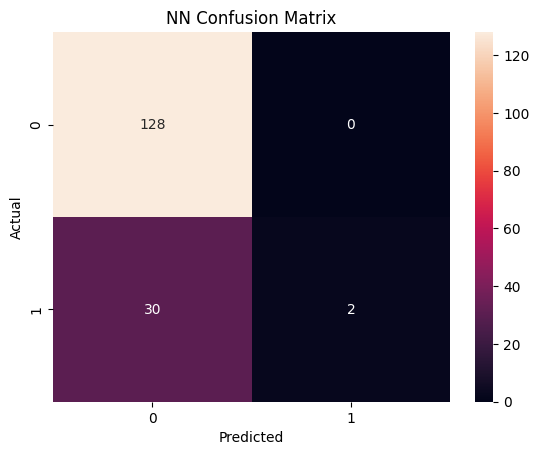

In [46]:
cm_nn = confusion_matrix(y_test, y_pred_nn)

sns.heatmap(cm_nn, annot=True, fmt="d")
plt.title("NN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
results.loc[3] = ["Neural Network", acc_nn, pre_nn, rec_nn, f1_nn]

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.85625,0.621622,0.71875,0.666667
1,Random Forest,0.85625,0.655172,0.59375,0.622951
2,KNN,0.78125,0.400000,0.18750,0.255319
3,Neural Network,0.81250,1.000000,0.06250,0.117647


The nn performed worse than Log Regression because it had a much lower F1-score Although the nn achieved high precision its recall was very low which means it did not detect most of the positive class Since the dataset is imbalanced F1-score is the main metric so Log Regression is the best model